[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)]
(https://github.com/VinayakSingh-creator/Beam_Envelope_Simulation/blob/main/Transverse_beam_dynamics.ipynb)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


###Initial Beam Distribution

In [ ]:
aperture = 1.5e-3  # 1.5 mm
N = 10000

ss = 0.05 # source spread

qs = np.random.random(N)*np.pi*2
rs = np.random.random(N)*0.25e-3
x0 = rs*np.cos(qs)*ss
y0 = rs*np.sin(qs)*ss
# x0 = np.zeros(N)  #np.random.normal(mean, sigma, number_of_particles)
xd=np.random.normal(0,0.25e-3,N) #sigma-in mrad
# y0=np.zeros(N)
yd=np.random.normal(0,0.25e-3,N)

beam_x=np.vstack((x0,xd))   #beam_x and beam_y contain the actual particles.
beam_y=np.vstack((y0,yd))



###Transfer Matrices

In [ ]:
def M_F(s,k):
  Q = s*np.sqrt(k)
  L = 1/np.sqrt(k)
  return np.array([np.cos(Q),L*np.sin(Q),-np.sin(Q)/L,np.cos(Q)]).reshape(2,2)

def M_D(s,k):
    Q = s*np.sqrt(abs(k))
    L = 1/np.sqrt(abs(k))

    return np.array([
        np.cosh(Q),
        L*np.sinh(Q),
        np.sinh(Q)/L,
        np.cosh(Q)
    ]).reshape(2,2)

def M_B(s,R):
  Q=s/R
  return np.array([np.cos(Q),R*np.sin(Q),-np.sin(Q)/R,np.cos(Q)]).reshape(2,2)

def Drift(s):
  return np.array([1,s,0,1]).reshape(2,2)

def TLfocus(f):
  return np.array([1,0,-1/f,1]).reshape(2,2) #focusing in y

def TLdefocus(f):
  return np.array([1,0,1/f,1]).reshape(2,2) #defocusing in x


###Envelope Storage

In [ ]:
env_x = [np.percentile(np.abs(beam_x[0]),95)]  #env_x and env_y are not particles. They are just a record of the beam size at different positions along the beamline.
env_y = [np.percentile(np.abs(beam_y[0]),95)]
transmission = [1.0]  #transmission means ratio of surviving and initial particles
s_vals = [0.0]
s = 0.0  #s is nominal trajectory
ds = 0.001 #propogation step size
beam_profiles = []



###Propagation Function

In [ ]:
def propagate(beam_x, beam_y, Mx, My):
  global s
  beam_x = Mx @ beam_x
  beam_y = My @ beam_y
  r = np.sqrt(beam_x[0]**2 + beam_y[0]**2)
  mask = (r < aperture)
  beam_x = beam_x[:, mask]  # : means keeps all rows of x and x'
  beam_y = beam_y[:, mask]  # mask means keeps only columns where mask condition is true
  s += ds    # updates postion after each step
  s_vals.append(s) # Append current s to s_vals

  # Suppose all particles are lost we need
  # Empty beam
  if beam_x.shape[1] == 0:
     env_x.append(np.nan)
     env_y.append(np.nan)
     transmission.append(0)
     return beam_x, beam_y


  #Beam Envelope
  env_x.append(np.percentile(np.abs(beam_x[0]),95)) #Since particle co ordinates are stored in meters hence this in mm therefore it is multiplied by 1000
  env_y.append(np.percentile(np.abs(beam_y[0]),95))

  #For transmission
  transmission.append(beam_x.shape[1]/N)
  return beam_x, beam_y

###Accelerator Lattice

In [ ]:
#Format:
#(type, length, additional parameters)
#Lengths are in meters.

k_e1 = 16.5
k_e2 = 8.0
kqf  = 5.95
kqd  = 6.0
k_qs = 10.0

f_edge = 1.95 # initial guess (can tune later)
f_edge2 = 3.5 # initial guess (can tune later)
lattice = [

    # -----------------------------
    # SOURCE REGION
    # -----------------------------z
    ("drift", 0.18),

    # -----------------------------
    # EINZEL 1
    # -----------------------------
    ("focus", 0.27, k_e1),
    ("drift", 0.40),

    # -----------------------------
    # ESA 1
    # -----------------------------
    ("drift", 0.551),
    ("drift", 1.01),

    # -----------------------------
    # EINZEL 2
    # -----------------------------
    ("focus", 0.27, k_e2),
    ("drift", 0.365),

    # -----------------------------
    # BENDING MAGNET (BI)
    # -----------------------------
    ("edge", f_edge),
    ("bend", 0.649, 0.58),
    ("edge", f_edge),
    ("drift", 0.72),

    # -----------------------------
    # QSNOUT
    # -----------------------------


    ("focus", 0.18, k_qs),

    ("drift", 2.50),

    # -----------------------------
    # QUADRUPOLE TRIPLET (FIXED TO 40 cm)
    # -----------------------------
    ("QF", 0.08, kqf),  #focusing in x & defocusing in y .
    ("drift", 0.04),
    ("QD", 0.16, kqd),
    ("drift", 0.04),
    ("QF", 0.08, kqf),
    ("drift", 0.30),

    # -----------------------------
    # SECOND BENDING MAGNET
    # -----------------------------
   ("edge", f_edge2),      # entrance → focus x
   ("bend", 1.263, 1.15),
   ("edge", f_edge2),      # exit → focus y
   ("drift", 1.405),

    # -----------------------------
    # ESA 2
    # -----------------------------
    ("drift", 1.531),
    ("drift", 0.15)
]



### Beam Propogation

In [ ]:
for element in lattice:

    etype = element[0]

    # -----------------------------------------
    # DRIFT
    # -----------------------------------------
    if etype == "drift":

        L = element[1]
        nsteps = int(L / ds)

        for _ in range(nsteps):

            M = Drift(ds)

            beam_x, beam_y = propagate(
                beam_x,
                beam_y,
                M,
                M
            )

        beam_profiles.append((etype, beam_x[0].copy(), beam_y[0].copy()))

    # -----------------------------------------
    # EINZEL LENS
    # -----------------------------------------
    elif etype == "focus":

        L = element[1]
        k = element[2]

        nsteps = int(L / ds)

        for _ in range(nsteps):

            # Focuses equally in x and y
            M = M_F(ds,k)

            beam_x, beam_y = propagate(
                beam_x,
                beam_y,
                M,
                M
            )
        beam_profiles.append((etype, beam_x[0].copy(), beam_y[0].copy()))

    # -----------------------------------------
    # QUADRUPOLE FOCUSING (QF)
    # -----------------------------------------
    elif etype == "QF":

        L = element[1]
        k = element[2]

        nsteps = int(L / ds)

        for _ in range(nsteps):

            Mx = M_F(ds,k)   # x focusing
            My = M_D(ds ,k)   # y defocusing

            beam_x, beam_y = propagate(
                beam_x,
                beam_y,
                Mx,
                My
            )
        beam_profiles.append((etype, beam_x[0].copy(), beam_y[0].copy()))
    # -----------------------------------------
    # QUADRUPOLE DEFOCUSING (QD)
    # -----------------------------------------
    elif etype == "QD":

        L = element[1]
        k = element[2]

        nsteps = int(L / ds)

        for _ in range(nsteps):

            Mx = M_D(ds , k)   # x defocusing
            My = M_F(ds ,k )   # y focusing

            beam_x, beam_y = propagate(
                beam_x,
                beam_y,
                Mx,
                My
            )
        beam_profiles.append((etype, beam_x[0].copy(), beam_y[0].copy()))
    # -----------------------------------------
    # THIN EDGE LENS
    # -----------------------------------------
    elif etype == "edge":

        f = element[1]

        fx = TLdefocus(f)
        fy = TLfocus(f)

        beam_x, beam_y = propagate(
            beam_x,
            beam_y,
            fx,
            fy
        )

        beam_profiles.append((etype, beam_x[0].copy(), beam_y[0].copy()))

    # -----------------------------------------
    # BENDING MAGNET
    # -----------------------------------------

    elif etype == "bend":

      L = element[1]
      R = element[2]

      nsteps = int(L/ds)

      for _ in range(nsteps):

        Mx = M_B(ds,R)

        # vertical plane behaves approximately as drift
        My = Drift(ds)

        beam_x, beam_y = propagate(
            beam_x,
            beam_y,
            Mx,
            My
        )

      beam_profiles.append((etype, beam_x[0].copy(), beam_y[0].copy()))


###Beam Envolope Plot

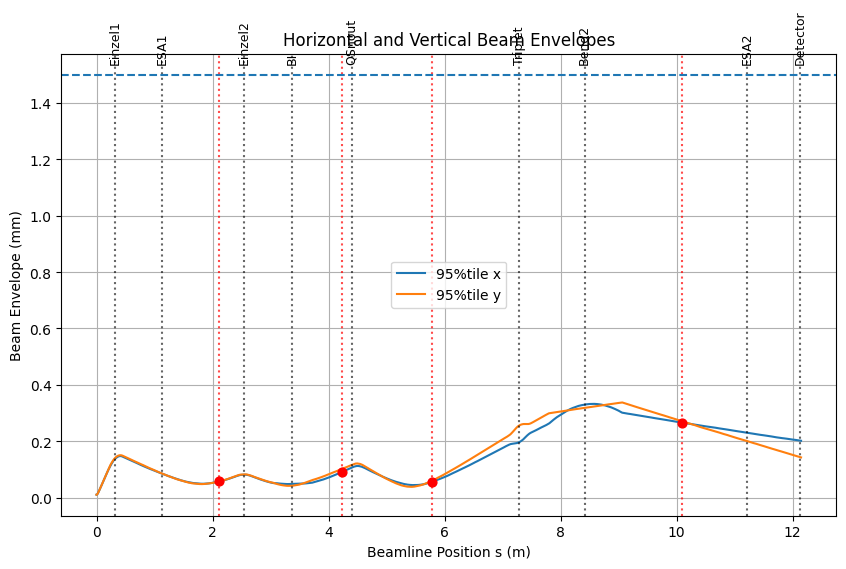

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    s_vals,
    np.array(env_x)*1000,
    label='95%tile x'
)

plt.plot(
   s_vals,
   np.array(env_y)*1000,
   label='95%tile y'
)
plt.xlabel("Beamline Position s (m)")

plt.ylabel("Beam Envelope (mm)")



plt.title("Horizontal and Vertical Beam Envelopes")
components = [
    (0.315, "Einzel1"),
    (1.126, "ESA1"),
    (2.546, "Einzel2"),
    (3.371, "BI"),
    (4.400, "QSnout"),
    (7.285, "Triplet"),
    (8.417, "Bend2"),
    (11.219, "ESA2"),
    (12.134, "Detector")
]

for pos, name in components:
    plt.axvline(pos, linestyle=':', color='black', alpha=0.6)  # dotted vertical
    plt.text(pos, 1.55, name, rotation=90, fontsize=9, ha='center')

aperture_positions = [2.12,4.24,5.78,10.1]   # add more if needed


for pos in aperture_positions:

    # find closest index in s_vals
    idx = np.argmin(np.abs(np.array(s_vals) - pos))

    # plot vertical dotted line
    plt.axvline(pos, linestyle=':', color='red', alpha=0.7)

    # plot dot ON the beam envelope (σx here)
    plt.scatter(pos, env_x[idx]*1000, color='red', s=40, zorder=5) # Changed env[idx] to env_x[idx]



plt.grid(True)

plt.axhline(1.5, linestyle='--')

plt.legend()

plt.show()

In [ ]:
total_length = 0

for elem in lattice:
    if elem[0] != "edge":
        total_length += elem[1]

print(total_length)

12.144


###Transmission Plot

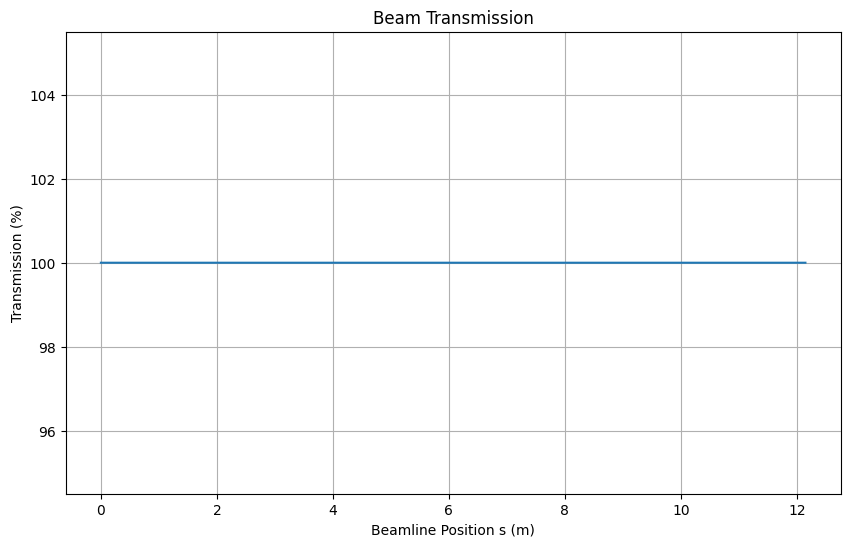

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    s_vals,
    np.array(transmission)*100
)

plt.xlabel("Beamline Position s (m)")

plt.ylabel("Transmission (%)")

plt.title("Beam Transmission")

plt.grid(True)

plt.show()

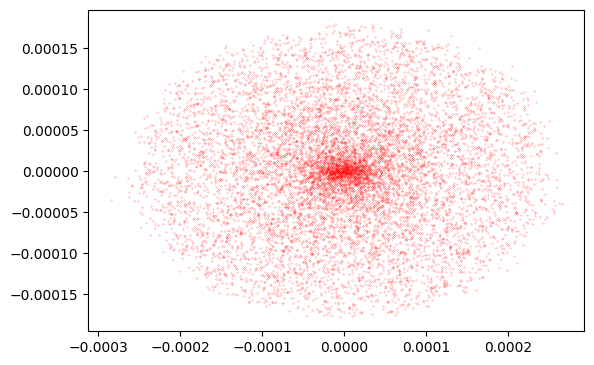

In [ ]:
plt.subplot(111 , aspect = 'equal')
plt.plot(beam_x[0], beam_y[0] , 'r.' ,ms = 0.3)

### Beam Plot at different Sections using Lattice

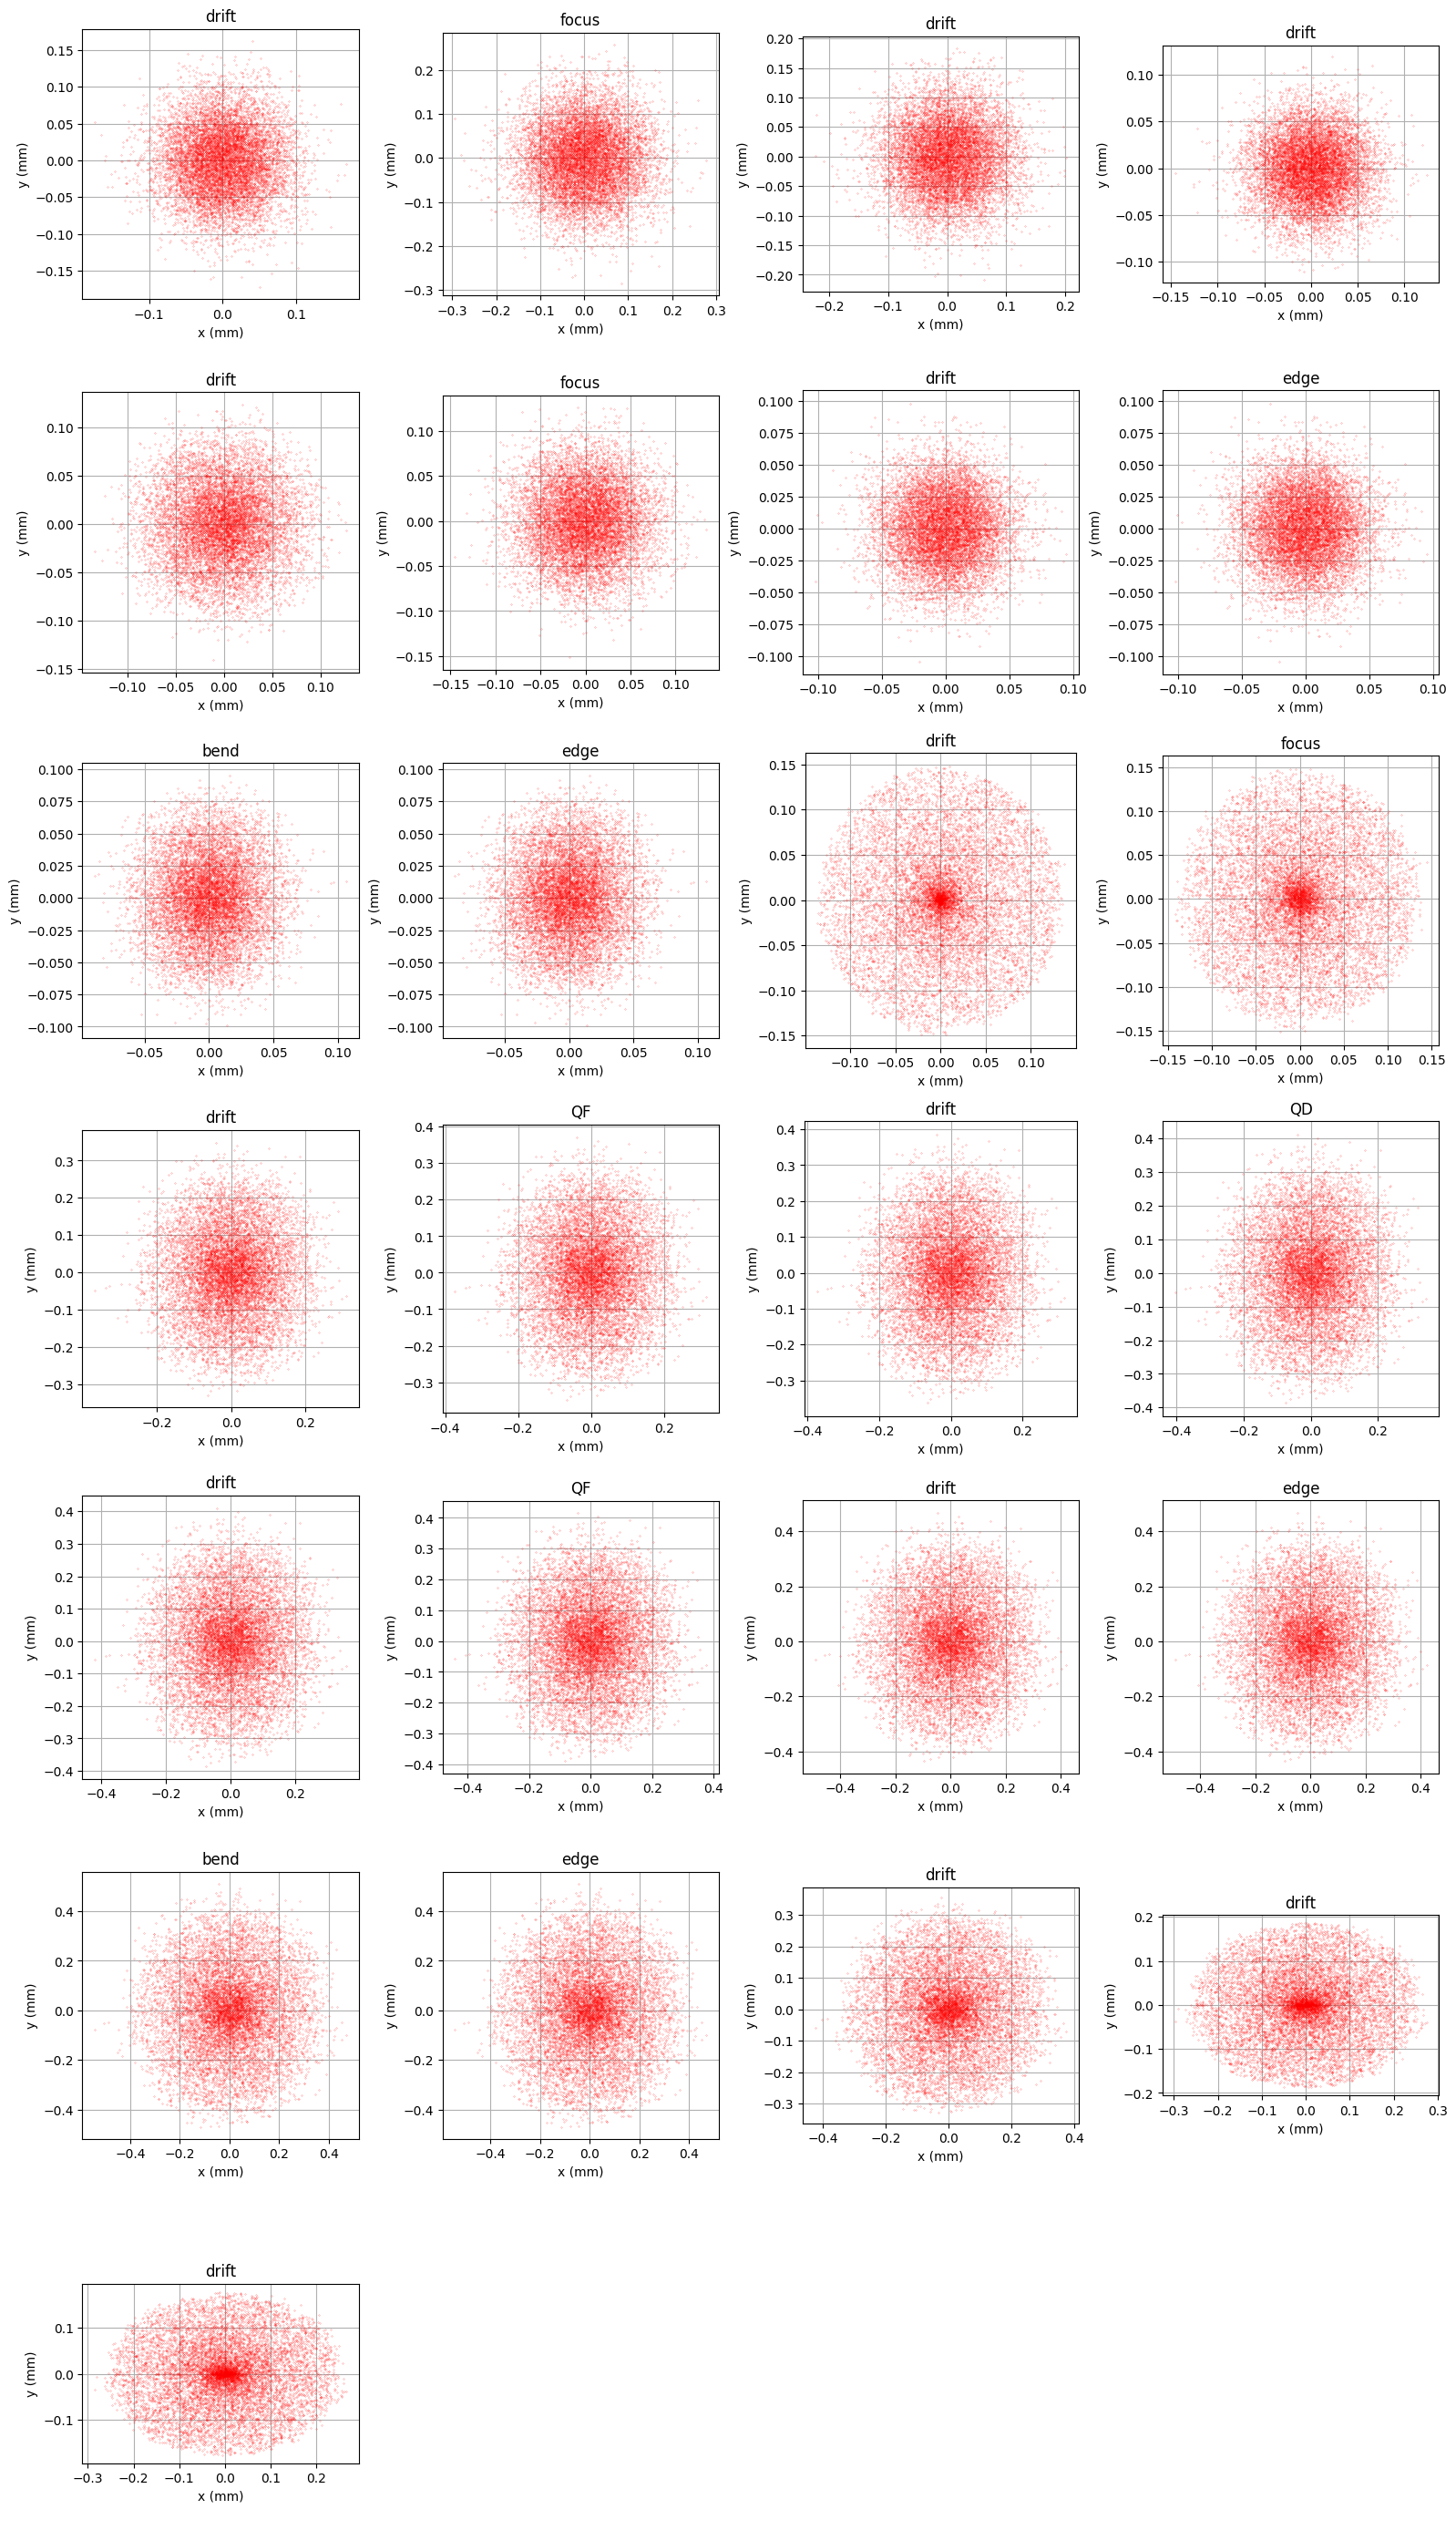

In [ ]:
import matplotlib.pyplot as plt

n = len(beam_profiles)

fig, axes = plt.subplots(
    int(np.ceil(n/4)),
    4,
    figsize=(16, 4*np.ceil(n/4))
)

axes = axes.flatten()

for ax, (name, x, y) in zip(axes, beam_profiles):

    ax.plot(
        x*1000,
        y*1000,
        'r.',
        ms=0.3
    )

    ax.set_title(name)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_aspect('equal')
    ax.grid(True)

for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()